In [1]:
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
az.style.use("arviz-darkgrid")
SEED = 7355608

In [3]:
data = bmb.load_data("cherry_blossoms")
data

,year,doy,temp,temp_upper,temp_lower
0,801,NaN,NaN,NaN,NaN
1,802,NaN,NaN,NaN,NaN
2,803,NaN,NaN,NaN,NaN
3,804,NaN,NaN,NaN,NaN
4,805,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1210,2011,99.0,NaN,NaN,NaN
1211,2012,101.0,NaN,NaN,NaN
1212,2013,93.0,NaN,NaN,NaN
1213,2014,94.0,NaN,NaN,NaN


In [4]:
data = data.dropna(subset=["doy"]).reset_index(drop=True)
data.shape

(827, 5)

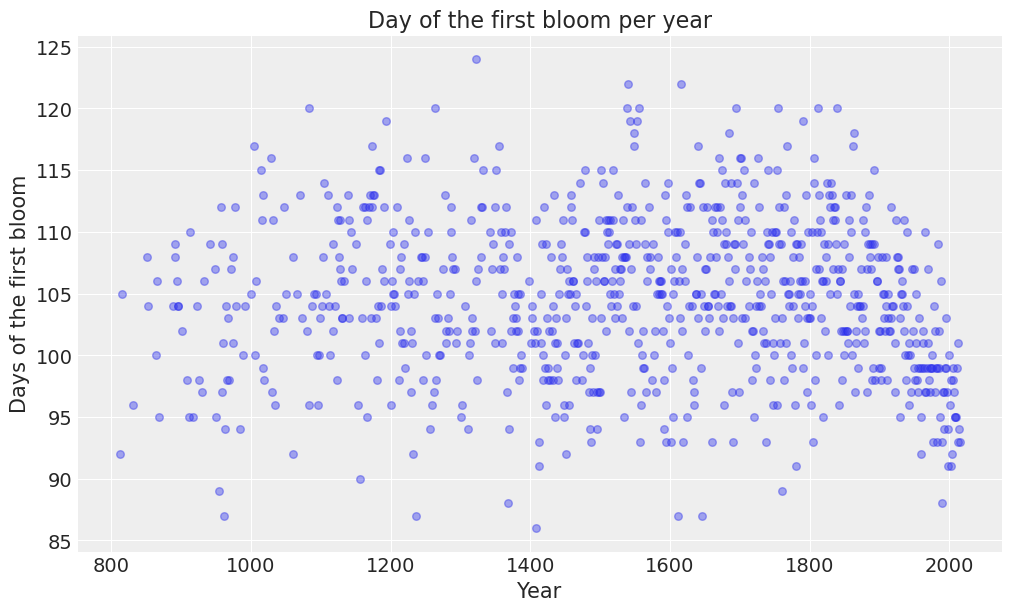

In [5]:
def plot_scatter(data, figsize=(10, 6)):
    _, ax = plt.subplots(figsize=figsize)
    ax.scatter(data["year"], data["doy"], alpha=0.4, s=30)
    ax.set_title("Day of the first bloom per year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Days of the first bloom")
    return ax

plot_scatter(data);

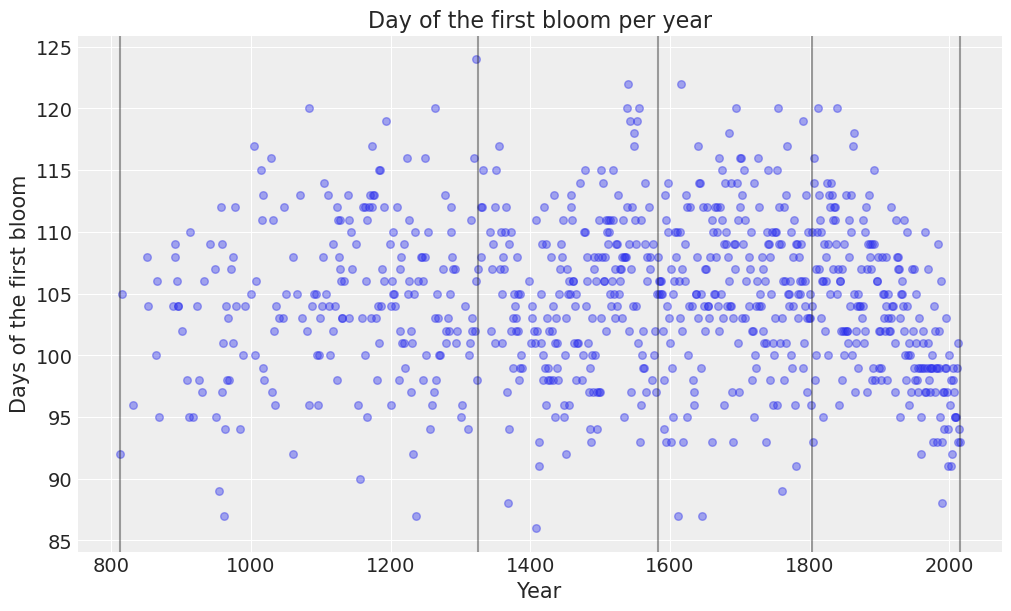

In [39]:
num_knots = 5
knots = np.quantile(data["year"], np.linspace(0, 1, num_knots))

def plot_knots(knots, ax):
    for knot in knots:
        ax.axvline(knot, color="0.1", alpha=0.4)
    return ax

ax = plot_scatter(data)
plot_knots(knots, ax);


In [40]:
iknots = knots[1:-1]

# Define dictionary of priors
priors = {
    "Intercept": bmb.Prior("Normal", mu=100, sigma=10),
    "common": bmb.Prior("Normal", mu=0, sigma=10), 
    "sigma": bmb.Prior("Exponential", lam=1)
}

# Define model
# The intercept=True means the basis also spans the intercept, as originally done in the book example.
model = bmb.Model("doy ~ bs(year, knots=iknots, intercept=True)", data, priors=priors)
model

       Formula: doy ~ bs(year, knots=iknots, intercept=True)
        Family: gaussian
          Link: mu = identity
  Observations: 827
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 100.0, sigma: 10.0)
            bs(year, knots=iknots, intercept=True) ~ Normal(mu: 0.0, sigma: 10.0)
        
        Auxiliary parameters
            sigma ~ Exponential(lam: 1.0)

In [41]:
def plot_spline_basis(basis, year, figsize=(10, 6)):
    df = (
        pd.DataFrame(basis)
        .assign(year=year)
        .melt("year", var_name="basis_idx", value_name="value")
    )

    _, ax = plt.subplots(figsize=figsize)

    for idx in df.basis_idx.unique():
        d = df[df.basis_idx == idx]
        ax.plot(d["year"], d["value"])
    
    return ax


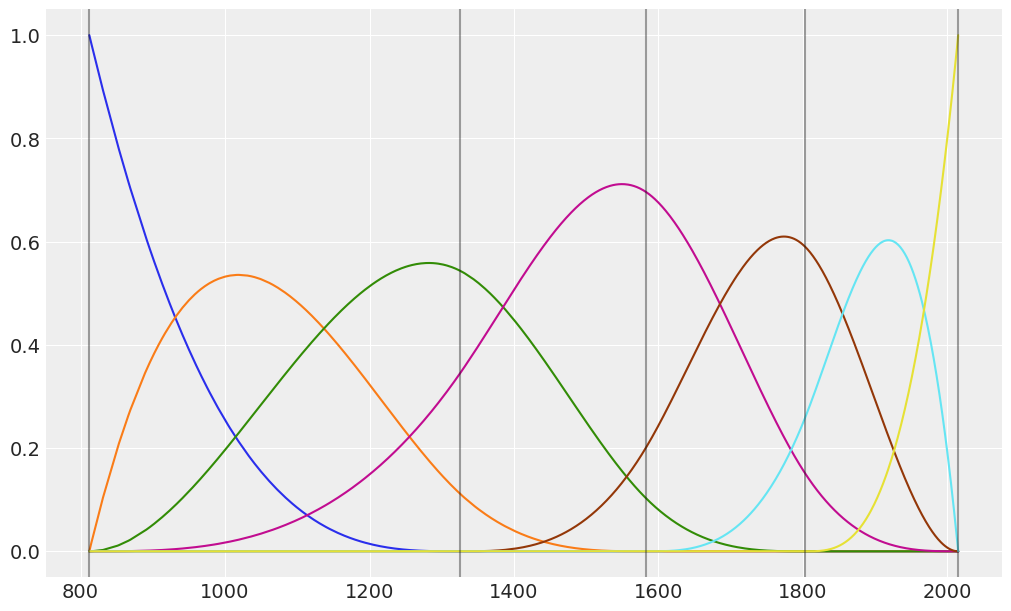

In [42]:
B = model.components["mu"].design.common["bs(year, knots=iknots, intercept=True)"]
ax = plot_spline_basis(B, data["year"].values)
plot_knots(knots, ax);

In [43]:
idata = model.fit(random_seed=SEED, idata_kwargs={"log_likelihood": True})

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, bs(year, knots=iknots, intercept=True)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [44]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,103.068,3.708,96.232,110.068,0.121,0.086,940.0,1249.0,1.01
"bs(year, knots=iknots, intercept=True)[0]",-5.171,4.158,-13.163,2.182,0.123,0.087,1143.0,1908.0,1.01
"bs(year, knots=iknots, intercept=True)[1]",5.195,4.304,-2.845,13.374,0.126,0.093,1164.0,1353.0,1.01
"bs(year, knots=iknots, intercept=True)[2]",0.070,4.022,-7.632,7.198,0.123,0.087,1071.0,1543.0,1.01
"bs(year, knots=iknots, intercept=True)[3]",2.124,3.847,-4.855,9.743,0.122,0.086,1000.0,1187.0,1.01
"bs(year, knots=iknots, intercept=True)[4]",4.156,3.897,-3.161,11.561,0.122,0.087,1017.0,1357.0,1.01
"bs(year, knots=iknots, intercept=True)[5]",1.845,3.934,-5.350,9.449,0.123,0.087,1019.0,1442.0,1.01
"bs(year, knots=iknots, intercept=True)[6]",-8.600,3.891,-15.833,-1.127,0.121,0.086,1027.0,1471.0,1.01
sigma,6.031,0.148,5.744,6.300,0.003,0.002,2700.0,2362.0,1.00


array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'bs(year, knots=iknots, intercept=True)'}>,
        <Axes: title={'center': 'bs(year, knots=iknots, intercept=True)'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

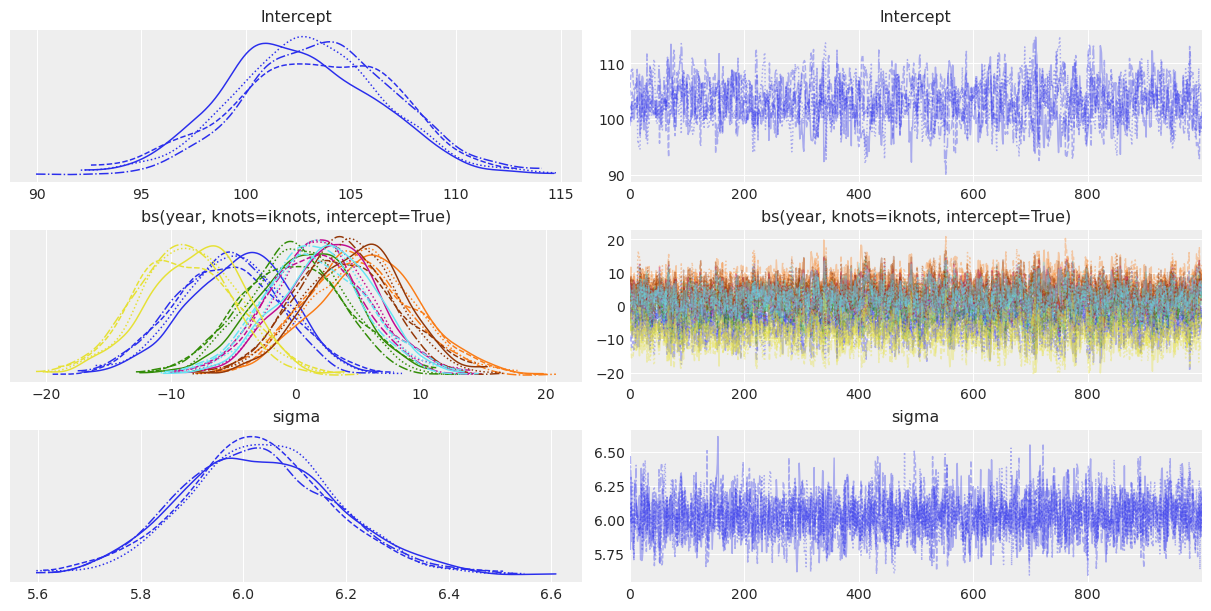

In [45]:
az.plot_trace(idata)

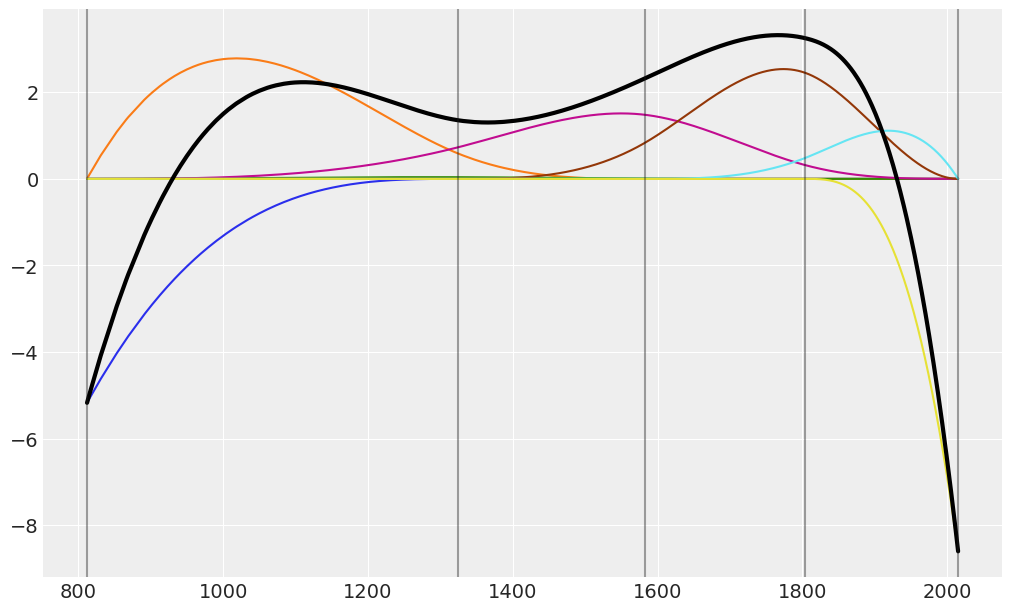

In [46]:
posterior_stacked = az.extract(idata)
wp = posterior_stacked["bs(year, knots=iknots, intercept=True)"].mean("sample").values

ax = plot_spline_basis(B * wp.T, data["year"].values)
ax.plot(data.year.values, np.dot(B, wp.T), color="black", lw=3)
plot_knots(knots, ax);

In [47]:
def plot_predictions(data, idata, model):
    # Create a test dataset with observations spanning the whole range of year
    new_data = pd.DataFrame({"year": np.linspace(data.year.min(), data.year.max(), num=500)})
    
    # Predict the day of first blossom
    model.predict(idata, data=new_data)

    posterior_stacked =  az.extract_dataset(idata)
    # Extract these predictions
    y_hat = posterior_stacked["mu"]

    # Compute the mean of the predictions, plotted as a single line.
    y_hat_mean = y_hat.mean("sample")

    # Compute 94% credible intervals for the predictions, plotted as bands
    hdi_data = np.quantile(y_hat, [0.01, 0.99], axis=1)

    # Plot obserevd data
    ax = plot_scatter(data)
    
    # Plot predicted line
    ax.plot(new_data["year"], y_hat_mean, color="firebrick")
    
    # Plot credibility bands
    ax.fill_between(new_data["year"], hdi_data[0], hdi_data[1], alpha=0.4, color="firebrick")
    
    # Add knots
    plot_knots(knots, ax)
    
    return ax


/var/folders/s6/w2v5p3l12nv4jz0cy2bqmqq00000gn/T/ipykernel_5656/1773944186.py:8: FutureWarning: extract_dataset has been deprecated, please use extract
  posterior_stacked =  az.extract_dataset(idata)


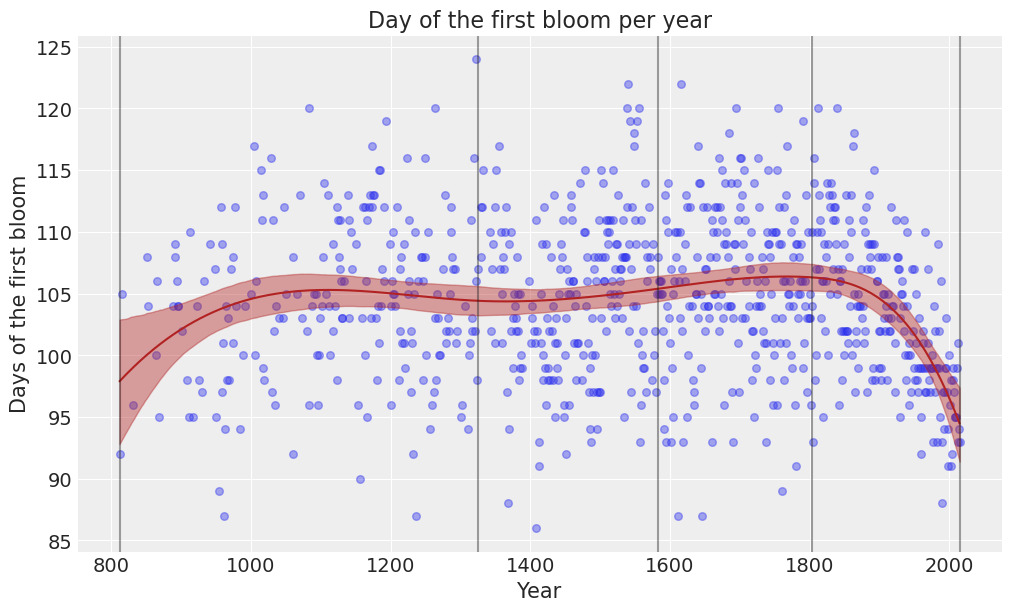

In [48]:
plot_predictions(data, idata, model);